# Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Math
from sympy import * 
from scipy.stats import multivariate_normal, norm

# Opgaver

## Opgave 9.6. PCA af 2D datasæt

In [3]:
x = np.array([[ -1, -0.5], 
              [ -1,   -1], 
              [  0,  0.5], 
              [0.5,  1.5],
              [  1,    1]])
xbar = np.mean(x, axis = 0)
Sigma = np.cov(x.T) # np.cov regner med en R^(D x N) matrix. 
_, U = np.linalg.eig(Sigma)
print(xbar)
print(Sigma)
print(U)

xtilde = lambda xbar, U, x : xbar - U@U.T@(x-xbar) 
# Ændre lige dimensioner så de passer
x = np.array([[  -1, -1,   0, 0.5, 1],
              [-0.5, -1, 0.5, 1.5, 1]])
xbar = np.mean(x, axis = 1)[:, np.newaxis]
M = 1
x_PCA = xtilde(xbar, U.T[:M-1, :], x)
print(x_PCA)

fig, ax = plt.subplots()
ax.plot()

[-0.1  0.3]
[[0.8   0.85 ]
 [0.85  1.075]]
[[-0.76147516 -0.64819409]
 [ 0.64819409 -0.76147516]]


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 0)

## Opgaver uge 6 


In [ ]:
x = np.array([-1,   1, 2])[:, np.newaxis]
t = np.array([ 1, 1.5, 3])[:, np.newaxis]
Phi = np.array([[1, x[0, 0]],
                [1,  x[1, 0]],
                [1,  x[2, 0]]])
w = np.linalg.inv(Phi.T @ Phi) @ (Phi.T @ t)

pprint(f"{w=}")
y = w.T @ Phi.T
print(y)

## Opgaver Uge 7

In [ ]:
X = np.array([[1, 1,  0, -2], 
              [2, 0, -1, -1]])
l = np.array([1, 1, 2, 2])

X_new = np.array([[2, 0, -1, -2],
                  [0, 0,  1,  0]])




# ? KNC method

mu1 = np.mean(X[:, l == 1], axis = 1)
mu2 = np.mean(X[:, l == 2], axis = 1)
cov1 = np.cov(X[:, l == 1])
cov2 = np.cov(X[:, l == 2])
print(f"{mu1=}")
print(f"{cov1=}")
print(f"{mu2=}")
print(f"{cov2=}")

# Eftersom at datasættet kun variere i enkelt dimensioner, så er det en normal normal distribution, som jeg skal have gang i. 
# Dog så kan det også konkluderes, på grund af ingen kovarians, at ingen af de nye punkter kan klassificeres.


# ? Diskriminant funktion ( Fisher )
X = X.T         # in R^{NxD}
Phi = np.hstack([np.ones((X.shape[0], 1)), X]) # [1, x_1, x_2, x_3, x_4]
pseudoInvers = lambda Phi : np.linalg.inv(Phi.T @ Phi) @ Phi.T          # R^{(D + 1)xN} . R^{Nx(D + 1)} . R^{(D + 1)xN} -> R^{(D + 1)xN}
W = pseudoInvers(Phi) @ l[:, np.newaxis]                                # R^{(D + 1)xN} . R^{Nx1} -> R^(D + 1)x1}
print(f"{W=}")



##  Opgaver uge 8

$$ w \propto S_W^{-1} (m_2 - m_1) \in R^{MxM}.R^{Mx1} \rightarrow R^{Mx1}$$

In [177]:
X = np.array([[1, 4, 8,  3, -1, -8], 
              [2, 6, 3, -1, -5, -9]])
X = X.T                                                             # X in [x1, x2, x3, x4].T in R^NxD                             
l = np.array([1, 1, 2, 2, 3, 3])

I1 = np.where(l == 1)[0]
I2 = np.where(l == 2)[0]
X1 = X[I1, :]
X2 = X[I2, :]

mu = np.array([np.mean(X1, axis = 0), np.mean(X2, axis = 0)]).T     # u in [u_1, u_2]

# cov1 = np.cov(X1, rowvar = False) 
# cov2 = np.cov(X2, rowvar = False)
# Ikke tilstrækkeligt med datapunkter til at lave en rigtig multivariate normal. 


$$ S_w = \sum_{n\in C_1}{(x_n - m_1)(x_n - m_1)^T} + \sum_{n\in C_2}{(x_n - m_2)(x_n - m_2)^T} $$

$$ X - \mu.T \in R^{NxD}.R^{1xD} \rightarrow R^{NxD} $$

[[-6.    ]
 [ 6.1875]]
[[17. 16.]
 [16. 16.]]


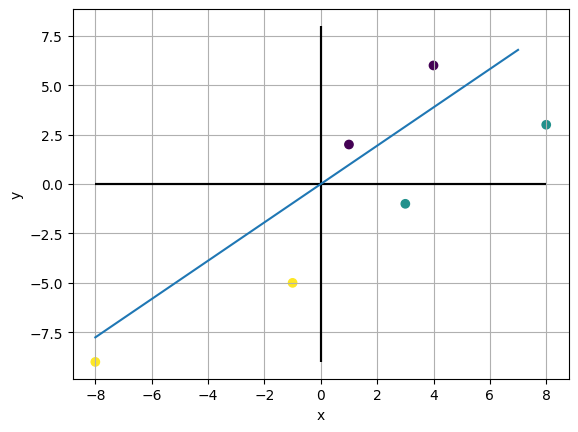

In [ ]:
dist1 = X1 - mu.T[0, :]                     
dist2 = X2 - mu.T[1, :]
# dist1 @ dist1.T                           # in R^NxM . R^MxN 
Sw = dist1.T @ dist1 + dist2.T @ dist2      # in R^MxN . R^NxM -> R^MxM

distmu = (mu.T[0, :] - mu.T[1, :])[:, np.newaxis]

w = np.linalg.inv(Sw) @ distmu              # in R^MxM . R^Mx1
print(w)
def scatterPlot(): 
    plt.scatter(X[:, 0], X[:, 1], c=l, cmap='viridis')
    plt.grid(); plt.vlines([0, 0], -9, 8, "black"); plt.hlines([0, 0], -8, 8, "black"); plt.xlabel("x"); plt.ylabel("y")

def decisionBoundary(w, b = 0): 
    x1 = np.arange(-8, 8)
    # y = w1x1 + w2x2 
    # x2 = (y/w2) - w1x1/w2
    x2 = b/w[1] -w[0]*x1/w[1]
    plt.plot(x1, x2)
scatterPlot()
decisionBoundary(w)

### Biasing

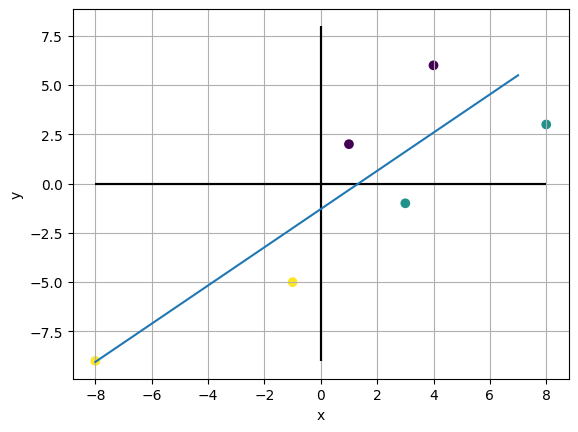

In [179]:
scatterPlot()
decisionBoundary(w, -8)

$$ y = W^Tx \quad W \in \mathbb{R}^{D\times D'} $$
Løsning findes for 
$$ S_W^{-1}S_B w = \lambda w $$
Så hvis jeg finder 
$$ W \in [w_1, w_2, ..., w_{K - 1}] $$
Som svarer til egenvektorer for de K - 1 største egenværdier.
$$ S_w = \sum_{n\in C_1}{(x_n - m_1)(x_n - m_1)^T} + \sum_{n\in C_2}{(x_n - m_2)(x_n - m_2)^T} $$
$$ S_B = \sum_{k = 1}^K N_k (m_k - m)(m_k - m)^T $$

$$ m = \frac{1}{N} \sum_{n = 1}^N {x_j} $$
Så m modsat den klasse specifikke middelværdi, er bare en enkelt middelværdi for alle datapunkter, uanset klasse.

In [180]:
# Hjælpeting
I_C = lambda k : np.where(l == k)[0]
K = np.max(l) + 1

Nclass = np.array([X[I_C(k)].shape[0] for k in range(1, K)])                # in [N_1, N_2, N_3] 
mu = np.mean(X, axis = 0)[:, np.newaxis]                                    #                       in R^{Dx1} 
muclass = np.array([np.mean(X[I_C(k)], axis = 0) for k in range(1, K)]).T   # in [mu_1, mu_2, mu_3] in R^{DxK}

betweenClassDist = muclass - mu                                             # in R^{DxK} - R^{Dx1} -> R^{DxK}
Sb = Nclass * betweenClassDist @ betweenClassDist.T                         # in R^{1xK}*R^{DxK} -> R^{DxK} . R^{KxD} -> R^{DxD} 

withinClassDist = np.array([X[I_C(k)] - muclass.T[k - 1, :][:, np.newaxis].T for k in range(1, K)]) # (in R^{N_kxD} - R^{1xD} -> R^{N_KxD}) -> R^{K x N_K x D}
Sw = np.sum([
    distk.T @ distk for distk in withinClassDist                            # in R^{DxN_k} . R^{N_kxD} -> R^{DxD}
], axis = 0)

eigvals, eigv = np.linalg.eig(np.linalg.inv(Sw) @ Sb)
print(eigvals)
print(eigv[:, 1]) # Er størst
W = np.hstack([eigv[:, 1][:, np.newaxis], eigv[:, 0][:, np.newaxis]])       # in [w1, w2]
print(f"{W=}")    

[ 2.20444872 18.37194017]
[ 0.5671532  -0.82361232]
W=array([[ 0.5671532 , -0.92010577],
       [-0.82361232,  0.39166997]])


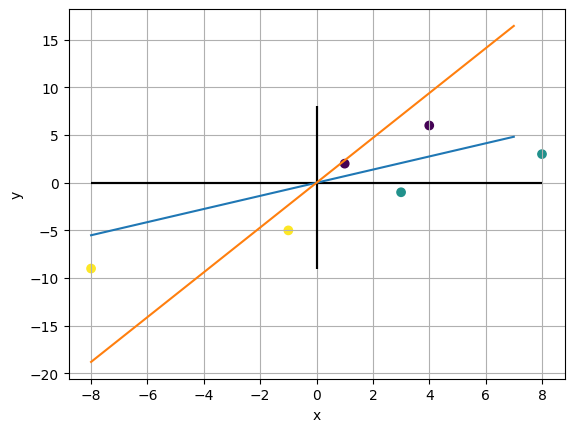

In [181]:
scatterPlot()
decisionBoundary(W[:, 0], 0)
decisionBoundary(W[:, 1], 0)

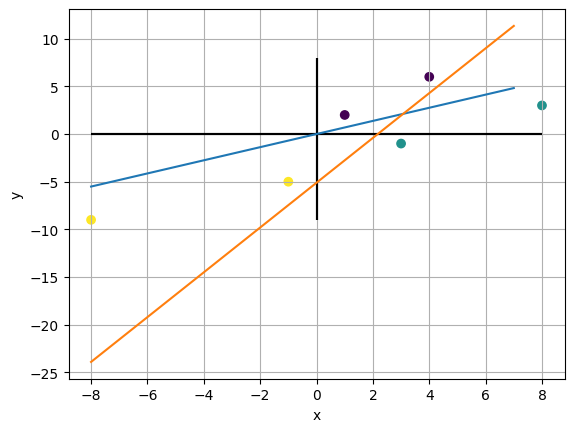

In [182]:
scatterPlot()
decisionBoundary(W[:, 0], 0)
decisionBoundary(W[:, 1], -2)